# So Sánh Việt Nam với các nước cạnh tranh FDI về độ mở kinh tế và sức hút dòng vốn

Khi đặt hai quốc gia này cạnh nhau, bạn sẽ thấy rõ sự khác biệt giữa hai loại hình "Độ mở":

Singapore: Độ mở dựa trên Dịch vụ và Tài chính (Hub cảng biển, trung tâm tài chính toàn cầu).

Việt Nam: Độ mở dựa trên Sản xuất và Gia công (Công xưởng thế giới).

Việc so sánh giúp trả lời câu hỏi: Việt Nam cần làm gì để nâng cấp từ một nước gia công thành một trung tâm dịch vụ giá trị cao như Singapore?

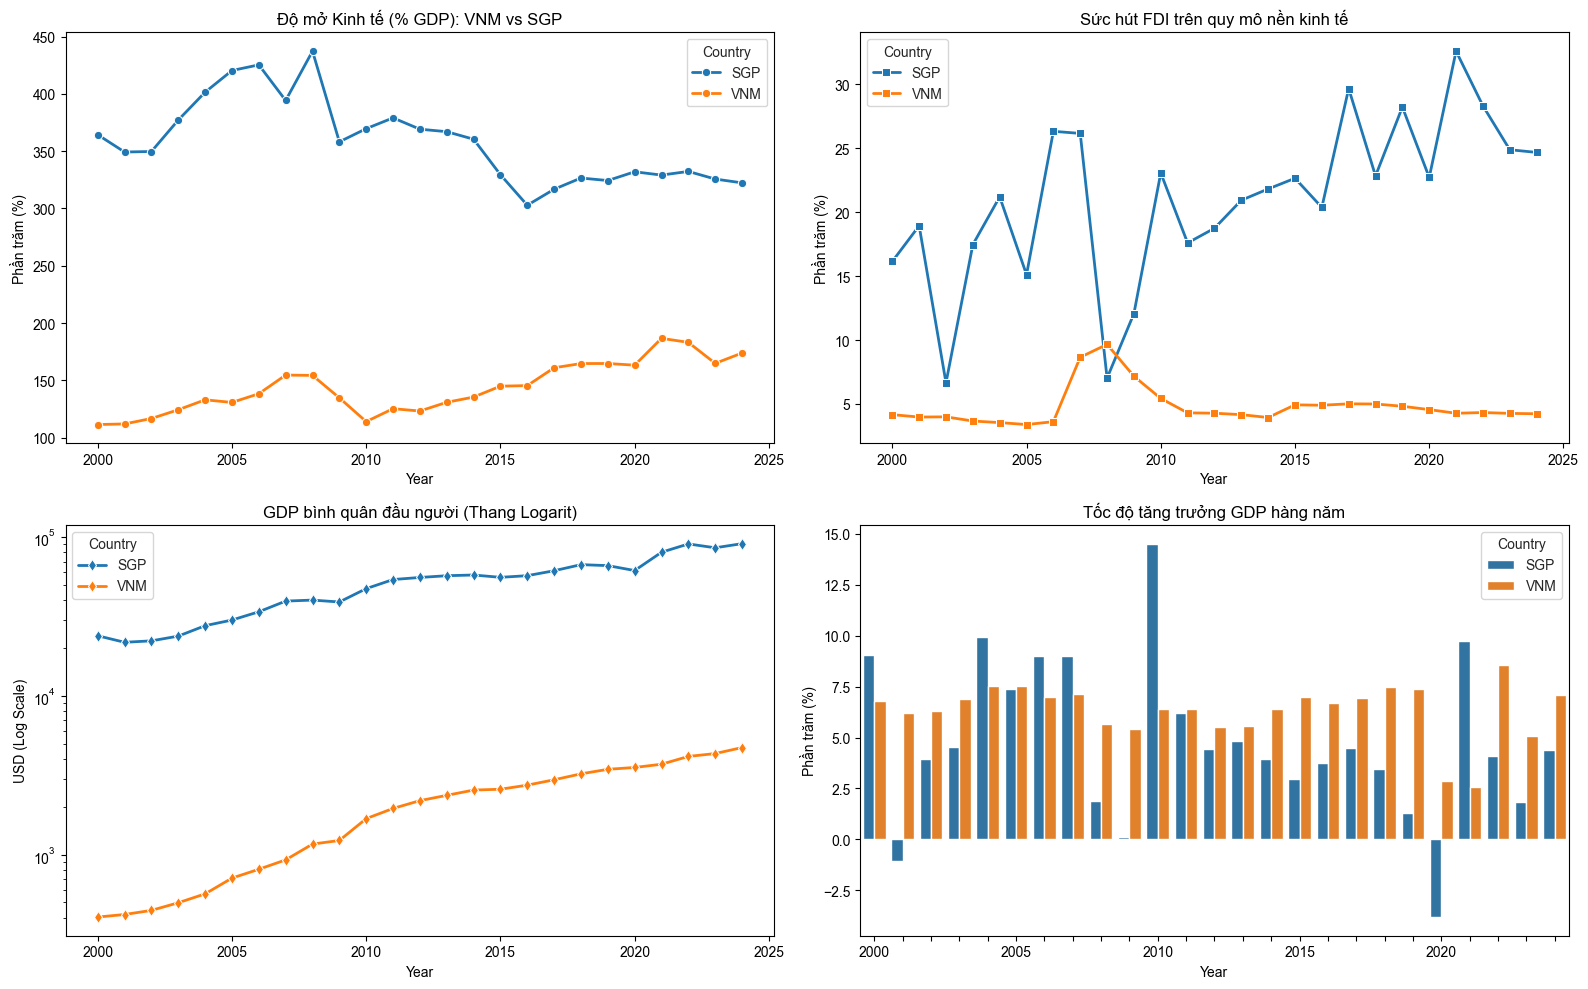

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
file_path = 'cleaned_data/information/panel_macro_cleaned.csv'
df = pd.read_csv(file_path)

# 2. Lọc dữ liệu VNM và SGP từ năm 2000 trở đi
countries = ['VNM', 'SGP']
compare_df = df[(df['Country'].isin(countries)) & (df['Year'] >= 2000)].copy()

# 3. Thiết lập biểu đồ đa khung (Subplots)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.set_style("whitegrid")

# Biểu đồ 1: Độ mở kinh tế (% GDP)
sns.lineplot(ax=axes[0, 0], data=compare_df, x='Year', y='Economic_Openness_Pct', hue='Country', marker='o', linewidth=2)
axes[0, 0].set_title('Độ mở Kinh tế (% GDP): VNM vs SGP', fontsize=12)
axes[0, 0].set_ylabel('Phần trăm (%)')

# Biểu đồ 2: Tỷ trọng FDI trên GDP
sns.lineplot(ax=axes[0, 1], data=compare_df, x='Year', y='FDI_to_GDP_Pct', hue='Country', marker='s', linewidth=2)
axes[0, 1].set_title('Sức hút FDI trên quy mô nền kinh tế', fontsize=12)
axes[0, 1].set_ylabel('Phần trăm (%)')

# Biểu đồ 3: GDP bình quân đầu người (Dùng thang Log để thấy rõ xu hướng tăng trưởng)
sns.lineplot(ax=axes[1, 0], data=compare_df, x='Year', y='GDP_Per_Capita_USD', hue='Country', marker='d', linewidth=2)
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('GDP bình quân đầu người (Thang Logarit)', fontsize=12)
axes[1, 0].set_ylabel('USD (Log Scale)')

# Biểu đồ 4: Tốc độ tăng trưởng GDP
sns.barplot(ax=axes[1, 1], data=compare_df, x='Year', y='GDP_Growth_Pct', hue='Country')
axes[1, 1].set_title('Tốc độ tăng trưởng GDP hàng năm', fontsize=12)
axes[1, 1].set_ylabel('Phần trăm (%)')
# Chỉ hiển thị một số mốc năm trên trục X cho đỡ rối
for ind, label in enumerate(axes[1, 1].get_xticklabels()):
    if ind % 5 == 0: label.set_visible(True)
    else: label.set_visible(False)

plt.tight_layout()
plt.show()

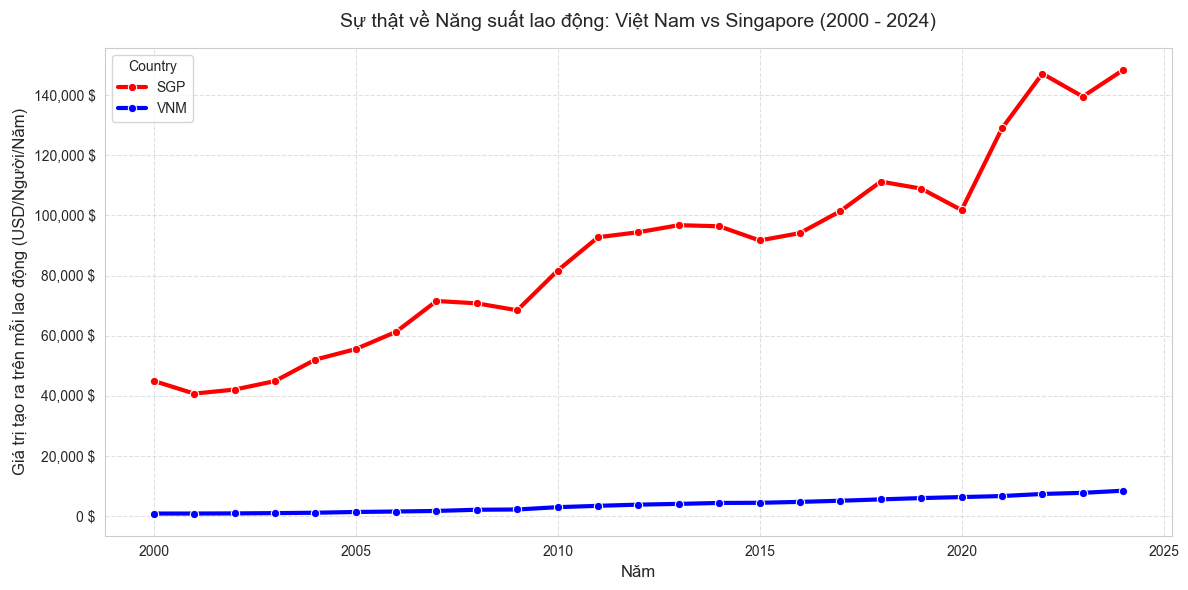


--- NĂNG SUẤT LAO ĐỘNG NĂM 2024 ---
Việt Nam: ~ 8,401 USD/người
Singapore: ~ 148,366 USD/người
=> 1 lao động Singapore tạo ra giá trị BẰNG 17.7 lao động Việt Nam cộng lại.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
df = pd.read_csv('cleaned_data/information/panel_macro_cleaned.csv')

# 2. Lọc VNM và SGP từ năm 2000
compare_df = df[(df['Country'].isin(['VNM', 'SGP'])) & (df['Year'] >= 2000)].copy()

# 3. TẠO BIẾN MỚI: Năng suất lao động (Giá trị tạo ra trên 1 người lao động)
# Lưu ý: Cột Labor_Force_Total là tổng số người trong lực lượng lao động
compare_df['Productivity_per_Worker_USD'] = compare_df['GDP_Current_USD'] / compare_df['Labor_Force_Total']

# 4. Trực quan hóa
plt.figure(figsize=(12, 6))

# Vẽ đường Năng suất
sns.lineplot(data=compare_df, x='Year', y='Productivity_per_Worker_USD', 
             hue='Country', marker='o', linewidth=3, palette=['red', 'blue'])

plt.title('Sự thật về Năng suất lao động: Việt Nam vs Singapore (2000 - 2024)', fontsize=14, pad=15)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Giá trị tạo ra trên mỗi lao động (USD/Người/Năm)', fontsize=12)

# Chuyển trục Y sang định dạng tiền tệ cho dễ đọc
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,} $".format(int(x))))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 5. In ra số liệu so sánh năm mới nhất để thấy độ lệch (Multiple)
latest_year = compare_df['Year'].max()
vnm_prod = compare_df[(compare_df['Country'] == 'VNM') & (compare_df['Year'] == latest_year)]['Productivity_per_Worker_USD'].values[0]
sgp_prod = compare_df[(compare_df['Country'] == 'SGP') & (compare_df['Year'] == latest_year)]['Productivity_per_Worker_USD'].values[0]

print(f"\n--- NĂNG SUẤT LAO ĐỘNG NĂM {latest_year} ---")
print(f"Việt Nam: ~ {vnm_prod:,.0f} USD/người")
print(f"Singapore: ~ {sgp_prod:,.0f} USD/người")
print(f"=> 1 lao động Singapore tạo ra giá trị BẰNG {sgp_prod/vnm_prod:.1f} lao động Việt Nam cộng lại.")

Mức năng suất ~148,000 USD/người của Singapore và ~8,400 USD/người của Việt Nam không đơn thuần là sự chênh lệch về sự chăm chỉ, mà là sự chênh lệch tuyệt đối về Mô hình tăng trưởng. Dưới đây là phân tích đa chiều về thực trạng này, đi kèm phương án giải quyết và hướng mở rộng chuyên sâu để bạn hoàn thiện toàn bộ dự án phân tích.

### 1. Phân tích đa góc độ về chênh lệch Năng suất (17.7 lần)
Góc độ rào cản (Nhược điểm): Cú va chạm với "Bẫy thu nhập trung bình"
Mức 8,401 USD/người/năm (tương đương khoảng 700 USD/tháng) phản ánh đúng giới hạn của việc lấy lao động giá rẻ và gia công lắp ráp làm động lực. Khi nền kinh tế chỉ thực hiện các công đoạn có giá trị gia tăng thấp nhất trong chuỗi cung ứng (như may mặc, lắp ráp linh kiện), năng suất sẽ chạm một "trần kính" không thể vượt qua. Dù công nhân có làm thêm bao nhiêu ca, họ cũng không thể tạo ra giá trị bằng một hệ thống thuật toán giao dịch tài chính tự động tại Singapore.

Góc độ lợi thế (Ưu điểm): Dư địa thu hút vốn ngắn hạn
Ngược lại, chính mức năng suất và chi phí lao động ở ngưỡng 8,400 USD này lại là "thỏi nam châm" giữ chân các tập đoàn FDI trong bối cảnh họ đang rời bỏ Trung Quốc (nơi chi phí đã tăng rất cao). Lợi thế này giúp duy trì tỷ lệ thất nghiệp thấp và đảm bảo an sinh xã hội trong giai đoạn chuyển tiếp.

### 2. Phương án giải quyết đề xuất (Tầm nhìn vĩ mô)
Để thu hẹp con số 17.7 lần này, nền kinh tế buộc phải có những dịch chuyển mang tính cấu trúc:

Chuyển đổi từ "Made in Vietnam" sang "Created in Vietnam": Buộc phải nâng cấp chuỗi giá trị. Thay vì chỉ nhập khẩu linh kiện điện tử về lắp ráp (khiến Cán cân thương mại có thể thặng dư nhưng GNI rò rỉ mạnh), cần đầu tư ngân sách lớn vào R&D (Nghiên cứu & Phát triển).

Số hóa và Tối ưu hóa bằng Dữ liệu: Mọi ngành nghề từ nông nghiệp, logistics đến sản xuất phải được gắn với hạ tầng công nghệ. Việc ứng dụng các kiến trúc dữ liệu hiện đại (như Data Lakehouse) vào quản trị chuỗi cung ứng nội địa sẽ giúp tự động hóa quy trình, giảm chi phí rườm rà, từ đó tăng giá trị đầu ra trên mỗi nhân sự kỹ thuật.

Dịch chuyển cơ cấu lao động: Rút dần lao động khỏi khu vực nông nghiệp (nơi năng suất thấp nhất) và khu vực phi chính thức, đào tạo lại để đưa vào các ngành công nghiệp kỹ thuật cao và dịch vụ hiện đại.

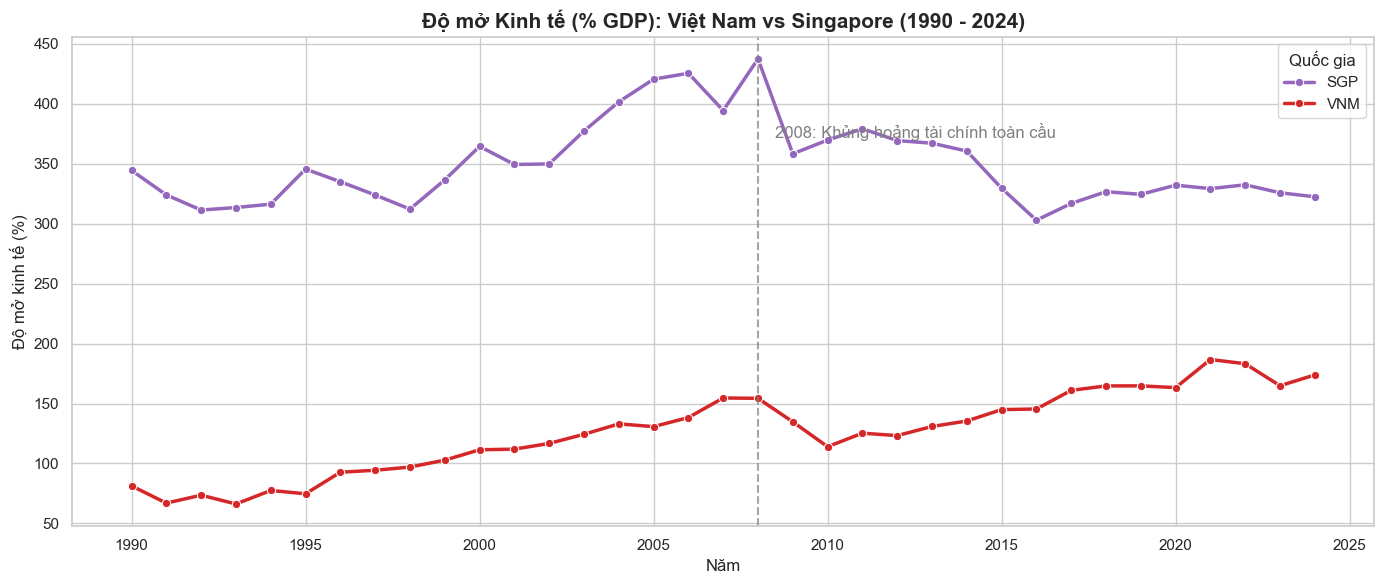

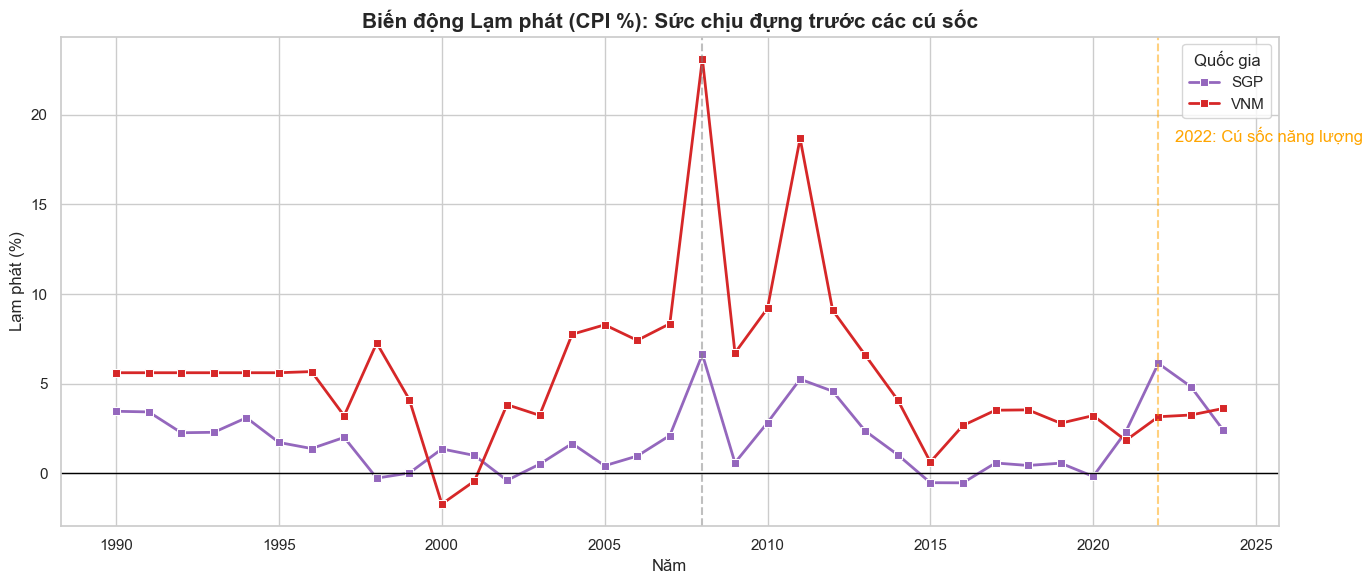

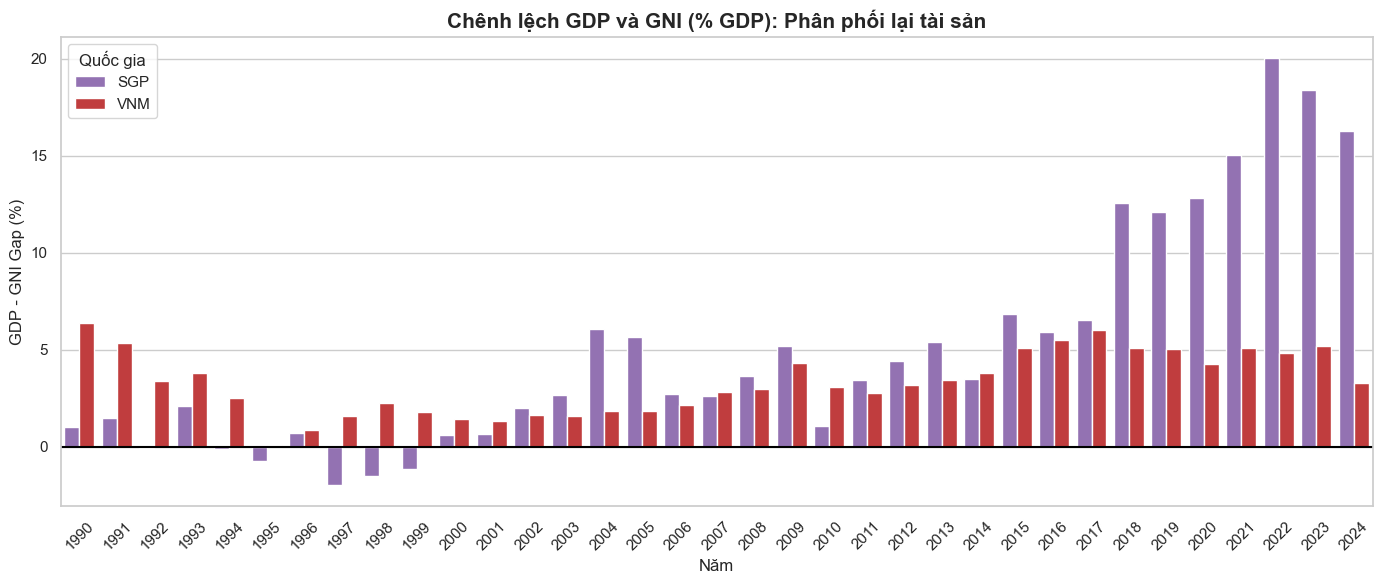

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style
sns.set_theme(style="whitegrid")

# Giả sử bạn đã load data từ trước:
df = pd.read_csv('cleaned_data/information/panel_macro_cleaned.csv')

# Lọc dữ liệu cho Việt Nam và Singapore
df_compare_sgp = df[df['Country'].isin(['VNM', 'SGP'])].copy()

# ==========================================
# BIỂU ĐỒ 1: QUỸ ĐẠO ĐỘ MỞ KINH TẾ (SỰ ĐIỀU CHỈNH CỦA SGP)
# ==========================================
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_compare_sgp, x='Year', y='Economic_Openness_Pct', hue='Country', 
             linewidth=2.5, marker='o', palette={'VNM': '#d62728', 'SGP': '#9467bd'})

# Thêm mốc khủng hoảng toàn cầu
plt.axvline(x=2008, color='gray', linestyle='--', alpha=0.7)
plt.text(2008.5, df_compare_sgp['Economic_Openness_Pct'].max()*0.85, '2008: Khủng hoảng tài chính toàn cầu', color='gray')

plt.title('Độ mở Kinh tế (% GDP): Việt Nam vs Singapore (1990 - 2024)', fontsize=15, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Độ mở kinh tế (%)', fontsize=12)
plt.legend(title='Quốc gia')
plt.tight_layout()
plt.show()

# ==========================================
# BIỂU ĐỒ 2: BỘ ĐẶM VĨ MÔ & KHẢ NĂNG CHỐNG SỐC (LẠM PHÁT)
# ==========================================
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_compare_sgp, x='Year', y='Inflation_CPI_Pct', hue='Country', 
             linewidth=2, marker='s', palette={'VNM': '#d62728', 'SGP': '#9467bd'})

plt.axhline(0, color='black', linewidth=1)
plt.axvline(x=2008, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=2022, color='orange', linestyle='--', alpha=0.5)
plt.text(2022.5, df_compare_sgp['Inflation_CPI_Pct'].max()*0.8, '2022: Cú sốc năng lượng', color='orange')

plt.title('Biến động Lạm phát (CPI %): Sức chịu đựng trước các cú sốc', fontsize=15, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Lạm phát (%)', fontsize=12)
plt.legend(title='Quốc gia')
plt.tight_layout()
plt.show()

# ==========================================
# BIỂU ĐỒ 3: BẢN CHẤT CỦA SỰ SIÊU MỞ (GDP VS GNI GAP)
# ==========================================
plt.figure(figsize=(14, 6))
sns.barplot(data=df_compare_sgp, x='Year', y='GDP_GNI_Gap_Pct', hue='Country', palette={'VNM': '#d62728', 'SGP': '#9467bd'})

plt.axhline(0, color='black', linewidth=1.5)
plt.title('Chênh lệch GDP và GNI (% GDP): Phân phối lại tài sản', fontsize=15, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('GDP - GNI Gap (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Quốc gia')
plt.tight_layout()
plt.show()